## Using the question-answering pipeline

we can use the question-answering pipeline like this to get the answer to a question:

In [6]:
from transformers import pipeline

question_answerer= pipeline("question-answering")

context = """
Transformers is backed by the three most popular deep learning libraries — Jax, PyTorch, and TensorFlow — with a seamless integration
between them. It's straightforward to train your models with one before loading them for inference with the other.
"""
question = "Which deep learning libraries back Transformers?"

question_answerer(question=question, context=context)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'score': 0.9743993431839044,
 'start': 76,
 'end': 104,
 'answer': 'Jax, PyTorch, and TensorFlow'}

#### Long context example

In [7]:
long_context = """
Transformers: State of the Art NLP

Transformers provides thousands of pretrained models to perform tasks on texts such as classification, information extraction,
question answering, summarization, translation, text generation and more in over 100 languages.
Its aim is to make cutting-edge NLP easier to use for everyone.

 Transformers provides APIs to quickly download and use those pretrained models on a given text, fine-tune them on your own datasets and
then share them with the community on our model hub. At the same time, each python module defining an architecture is fully standalone and
can be modified to enable quick research experiments.

Why should I use transformers?

1. Easy-to-use state-of-the-art models:
  - High performance on NLU and NLG tasks.
  - Low barrier to entry for educators and practitioners.
  - Few user-facing abstractions with just three classes to learn.
  - A unified API for using all our pretrained models.
  - Lower compute costs, smaller carbon footprint:

2. Researchers can share trained models instead of always retraining.
  - Practitioners can reduce compute time and production costs.
  - Dozens of architectures with over 10,000 pretrained models, some in more than 100 languages.

3. Choose the right framework for every part of a model's lifetime:
  - Train state-of-the-art models in 3 lines of code.
  - Move a single model between TF2.0/PyTorch frameworks at will.
  - Seamlessly pick the right framework for training, evaluation and production.

4. Easily customize a model or an example to your needs:
  - We provide examples for each architecture to reproduce the results published by its original authors.
  - Model internals are exposed as consistently as possible.
  - Model files can be used independently of the library for quick experiments.

 Transformers is backed by the three most popular deep learning libraries — Jax, PyTorch and TensorFlow — with a seamless integration
between them. It's straightforward to train your models with one before loading them for inference with the other.
"""
question_answerer(question=question, context=long_context)

{'score': 0.9700287683735951,
 'start': 1886,
 'end': 1913,
 'answer': 'Jax, PyTorch and TensorFlow'}

In [10]:
context = """
i am sakhawat hossen ,i live in chittagong , my father farid lives in Dhaka."""
question = "who is sakhawats father?"

question_answerer(question=question, context=context)

{'score': 0.9293915063753957, 'start': 56, 'end': 61, 'answer': 'farid'}

# Using a model for question answering

In [16]:
from transformers import AutoTokenizer,AutoModelForQuestionAnswering

model_checkpoint = "distilbert-base-cased-distilled-squad"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

inputs = tokenizer(question,context,return_tensors="pt")
outputs = model(**inputs)

In [17]:
outputs

QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-3.8034, -6.3172, -8.1851, -5.4701, -8.6597, -9.0382, -8.5551, -7.1158,
         -4.8557, -5.6617, -0.9409, -5.6311,  1.0272, -5.4233, -5.6932,  2.2174,
         -2.7795, -5.4664, -1.4823, -4.0160, -5.3563, -1.7845, -6.0513, -6.5047,
         -6.3063, -5.0873,  3.1457,  2.7322,  7.7430, -0.5457, -2.5267, -5.1540,
         -0.5638, -5.8882, -5.6617]], grad_fn=<CloneBackward0>), end_logits=tensor([[-2.1755, -5.8676, -8.2326, -9.3303, -7.9006, -7.9332, -7.3490, -6.1763,
         -5.5416, -6.0286, -3.3533, -6.0583, -6.1350, -4.2188, -2.3807, -3.9760,
          5.0736,  0.6203, -4.3932, -5.8334, -7.1919, -6.4823, -6.2277, -5.4847,
         -1.1968, -0.7480, -2.7828,  1.0678, -0.7720,  8.1020, -0.1783, -5.9487,
          0.9870,  1.1205, -6.0285]], grad_fn=<CloneBackward0>), hidden_states=None, attentions=None)

The `outputs` you see are the **raw outputs** of the Question Answering model. The model does **not** give the final answer text yet. Instead, it tells us:

* which token is more likely to be the **start** of the answer
* which token is more likely to be the **end** of the answer

This is what `start_logits` and `end_logits` are used for.

## What is `start_logits`?

`start_logits` is a score for **each token position** in the input. The model is trying to guess:

**“Does the answer start at this token?”**

For example, if your input has 66 tokens, then `start_logits` will also have 66 scores.

Like this:

* one score for token 0
* one score for token 1
* one score for token 2
* ...
* one score for token 65

The token with the **higher start logit** is more likely to be the place where the answer starts.

## What is `end_logits`?

`end_logits` works the same way, but it is used for the **end** of the answer.

The model is asking:

**“Does the answer end at this token?”**

So again, for every token in the input, the model gives one score to show how likely it is that the answer ends there.

## What are logits?

`logits` are **raw scores**. They are **not probabilities yet**.

In simple words:

* bigger value = the model is more confident
* smaller value = the model is less confident

Later, we can apply **softmax** to convert these scores into probabilities.


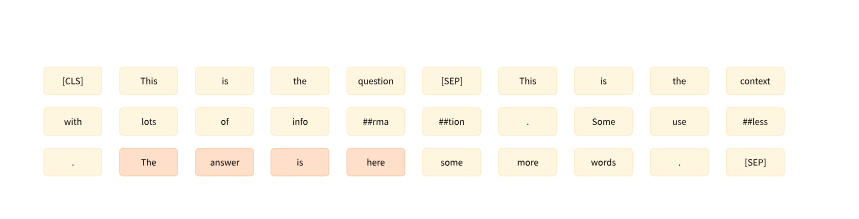

Models for question answering work a little differently from the models we’ve seen up to now. Using the picture above as an example, the model has been trained to predict the index of the token starting the answer (here 21) and the index of the token where the answer ends (here 24). This is why those models don’t return one tensor of logits but two: one for the logits corresponding to the start token of the answer, and one for the logits corresponding to the end token of the answer. Since in this case we have only one input containing 66 tokens, we get:

In [20]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits
print(start_logits.shape,end_logits.shape)

torch.Size([1, 35]) torch.Size([1, 35])


To convert those logits into probabilities, we will apply a softmax function — but before that, we need to make sure we mask the indices that are not part of the context. Our input is [CLS] question [SEP] context [SEP], so we need to mask the tokens of the question as well as the [SEP] token. We’ll keep the [CLS] token, however, as some models use it to indicate that the answer is not in the context.

Since we will apply a softmax afterward, we just need to replace the logits we want to mask with a large negative number. Here, we use -10000:

In [25]:
import torch 

sequence_ids = inputs.sequence_ids()
# Mask everything apart from the tokens of the context
mask = [i!=1 for i in sequence_ids]

# Umask the [CLS] token
mask =torch.tensor(mask)[None]

start_logits[mask] = -10000
end_logits[mask] = -10000

In [26]:
sequence_ids

[None,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 None,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 None]

Now that we have properly masked the logits corresponding to positions we don’t want to predict, we can apply the softmax:

In [27]:
start_probabilities = torch.nn.functional.softmax(start_logits, dim=-1)[0]
end_probabilities = torch.nn.functional.softmax(end_logits, dim=-1)[0]

At this stage, we could take the argmax of the start and end probabilities — but we might end up with a start index that is greater than the end index, so we need to take a few more precautions. We will compute the probabilities of each possible start_index and end_index where start_index <= end_index, then take the tuple (start_index, end_index) with the highest probability.

Assuming the events “The answer starts at start_index” and “The answer ends at end_index” to be independent, the probability that the answer starts at start_index and ends at end_index is:

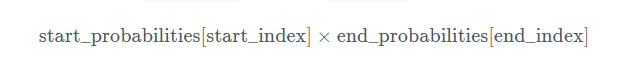

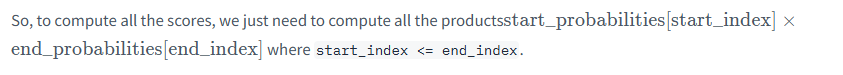

First let’s compute all the possible products:

In [28]:
scores = start_probabilities[:,None] * end_probabilities[None,:]

hen we’ll mask the values where start_index > end_index by setting them to 0 (the other probabilities are all positive numbers). The torch.triu() function returns the upper triangular part of the 2D tensor passed as an argument, so it will do that masking for us:

In [29]:
score = torch.triu(scores)

In [30]:
score

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.8639e-07, 2.1303e-07,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 1.0377e-09,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]], grad_fn=<TriuBackward0>)

Now we just have to get the index of the maximum. Since PyTorch will return the index in the flattened tensor, we need to use the floor division // and modulus % operations to get the start_index and end_index:

In [31]:
max_index = score.argmax().item()
start_index =max_index//score.shape[1]
end_index = max_index%score.shape[1]
print(score[start_index,end_index])

tensor(0.9291, grad_fn=<SelectBackward0>)


# Handling long contexts